<a href="https://colab.research.google.com/github/syedmahmoodiagents/computervision/blob/main/ObjectDetection_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import shutil

In [ ]:
import os

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
import os

In [ ]:
# os.listdir('Images')

['00004650.jpg',
 '00004638.jpg',
 '00004652.jpg',
 '00004657.jpg',
 '00004692.jpg',
 '00004666.jpg',
 '00004660.jpg',
 '00004676.jpg',
 '00004721.jpg',
 '00004729.jpg',
 '00004696.jpg',
 '00004715.jpg',
 '00004734.jpg',
 '00004739.jpg',
 '00004690.jpg',
 '00004723.jpg',
 '00004728.jpg',
 '00004717.jpg',
 '00004713.jpg',
 '00004681.jpg',
 '00004697.jpg',
 '00004695.jpg',
 '00004744.jpg',
 '00004700.jpg',
 '00004689.jpg',
 '00004705.jpg',
 '00004687.jpg',
 '00004735.jpg',
 '00004725.jpg',
 '00004732.jpg',
 '00004748.jpg',
 '00004675.jpg',
 '00004746.jpg',
 '00004710.jpg',
 '00004733.jpg',
 '00004716.jpg',
 '00004712.jpg',
 '00004736.jpg',
 '00004738.jpg',
 '00004702.jpg',
 '00004683.jpg',
 '00004727.jpg',
 '00004654.jpg',
 '00004662.jpg',
 '00004718.jpg',
 '00004679.jpg',
 '00004694.jpg',
 '00004711.jpg',
 '00004693.jpg',
 '00004730.jpg',
 '00004722.jpg',
 '00004701.jpg',
 '00004747.jpg',
 '00004724.jpg',
 '00004656.jpg',
 '00004743.jpg',
 '00004653.jpg',
 '00004709.jpg',
 '00004685.jpg

In [ ]:
df = pd.read_csv('labels.csv', sep=',', header=None)

In [ ]:
df

,0,1,2,3,4,5
0,0,pickup_truck,213,34,255,50
1,0,car,194,78,273,122
2,0,car,155,27,183,35
3,0,articulated_truck,43,25,109,55
4,0,car,106,32,124,45
...,...,...,...,...,...,...
351544,110590,car,18,57,97,98
351545,110591,articulated_truck,2,71,690,351
351546,110592,pickup_truck,3,240,214,378
351547,110592,car,465,111,507,135


In [ ]:
df[df[0] == 5570]

,0,1,2,3,4,5
17658,5570,car,247,182,292,246
17659,5570,car,544,365,628,454
17660,5570,car,402,123,447,151
17661,5570,car,356,149,401,190
17662,5570,car,118,288,192,397


In [ ]:
df.columns = ['image_id', 'class', 'x_min', 'y_min', 'x_max', 'y_max']

In [ ]:
df

,image_id,class,x_min,y_min,x_max,y_max
0,0,pickup_truck,213,34,255,50
1,0,car,194,78,273,122
2,0,car,155,27,183,35
3,0,articulated_truck,43,25,109,55
4,0,car,106,32,124,45
...,...,...,...,...,...,...
351544,110590,car,18,57,97,98
351545,110591,articulated_truck,2,71,690,351
351546,110592,pickup_truck,3,240,214,378
351547,110592,car,465,111,507,135


In [ ]:
df = df[df['image_id'] < 307]

In [ ]:
df

,image_id,class,x_min,y_min,x_max,y_max
0,0,pickup_truck,213,34,255,50
1,0,car,194,78,273,122
2,0,car,155,27,183,35
3,0,articulated_truck,43,25,109,55
4,0,car,106,32,124,45
...,...,...,...,...,...,...
993,305,car,625,169,698,228
994,305,car,267,95,377,151
995,306,motorized_vehicle,36,44,55,56
996,306,car,110,93,208,140


In [ ]:
# df['image_id'] = df['image_id'].apply(lambda x: f"{x:08d}")

In [ ]:
df

,image_id,class,x_min,y_min,x_max,y_max
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45
...,...,...,...,...,...,...
993,00000305,car,625,169,698,228
994,00000305,car,267,95,377,151
995,00000306,motorized_vehicle,36,44,55,56
996,00000306,car,110,93,208,140


In [ ]:
# Use iloc to pick the first 1000 labels
# df = df.iloc[:1000]

In [ ]:
df

,image_id,class,x_min,y_min,x_max,y_max
0,0,pickup_truck,213,34,255,50
1,0,car,194,78,273,122
2,0,car,155,27,183,35
3,0,articulated_truck,43,25,109,55
4,0,car,106,32,124,45
...,...,...,...,...,...,...
993,305,car,625,169,698,228
994,305,car,267,95,377,151
995,306,motorized_vehicle,36,44,55,56
996,306,car,110,93,208,140


In [ ]:
df[df['image_id'] == '00000000']

,image_id,class,x_min,y_min,x_max,y_max
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45


In [ ]:
for index, row in df.iterrows():
  print(index, row)
  print(row['image_id'])
  print(os.path.join('temp', f"{row['image_id']}.jpg"))
  break

0 image_id        00000000
class       pickup_truck
x_min                213
y_min                 34
x_max                255
y_max                 50
Name: 0, dtype: object
00000000
temp/00000000.jpg


In [ ]:
import cv2

In [ ]:
# Load the corresponding images
images_dir = 'Images/'
images = []
for index, row in df.iterrows():
    img_path = os.path.join(images_dir, f"{row['image_id']}.jpg")
    img = cv2.imread(img_path)
    if img is not None:
        images.append(img)
    else:
        print(f"Error loading image: {img_path}")


In [ ]:
df

,image_id,class,x_min,y_min,x_max,y_max
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45
...,...,...,...,...,...,...
993,00000305,car,625,169,698,228
994,00000305,car,267,95,377,151
995,00000306,motorized_vehicle,36,44,55,56
996,00000306,car,110,93,208,140


In [ ]:
len(images)

998

In [ ]:
# Analyze the distribution of vehicle types in the limited dataset
vehicle_types = df['class'].value_counts()
print("Distribution of vehicle types:")
print(vehicle_types)


Distribution of vehicle types:
class
car                      682
pickup_truck             111
motorized_vehicle         61
articulated_truck         30
work_van                  29
bus                       28
pedestrian                23
single_unit_truck         18
bicycle                   12
non-motorized_vehicle      5
motorcycle                 1
Name: count, dtype: int64


In [ ]:
df.sort_values('image_id')

,image_id,class,x_min,y_min,x_max,y_max
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45
...,...,...,...,...,...,...
993,00000305,car,625,169,698,228
994,00000305,car,267,95,377,151
996,00000306,car,110,93,208,140
995,00000306,motorized_vehicle,36,44,55,56


In [ ]:
# Address data quality issues arising from the discrepancy between labels and actual image filenames
# Sorting the image filenames
df = df.sort_values('image_id')

array([[[ 24,  24,  24],
        [ 17,  17,  17],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  2,   2,   2]],

       [[  0,   0,   0],
        [ 32,  32,  32],
        [ 55,  55,  55],
        ...,
        [  3,   3,   3],
        [  2,   2,   2],
        [  2,   2,   2]],

       [[ 34,  34,  34],
        [130, 130, 130],
        [199, 199, 199],
        ...,
        [  7,   7,   7],
        [  3,   3,   3],
        [  2,   2,   2]],

       ...,

       [[  4,   7,   5],
        [ 88,  91,  89],
        [148, 152, 147],
        ...,
        [  5,   5,   5],
        [  1,   1,   1],
        [  2,   2,   2]],

       [[  2,   5,   3],
        [ 87,  90,  88],
        [148, 152, 147],
        ...,
        [  5,   5,   5],
        [  0,   0,   0],
        [  2,   2,   2]],

       [[  3,   6,   4],
        [ 89,  92,  90],
        [146, 150, 145],
        ...,
        [  4,   4,   4],
        [  0,   0,   0],
        [  2,   2,   2]]], dtype=uint8)
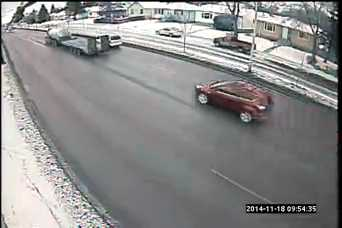

In [ ]:
images[0]

In [ ]:
if len(images) > 0:
    processed_images = [cv2.resize(img, (224, 224)) for img in images]  # Adjust dimensions as needed
    processed_images = np.array(processed_images)
    print("Images resized successfully.")

Images resized successfully.


In [ ]:
labels = df['class'].to_numpy()
bounding_boxes = df[['x_min', 'y_min', 'x_max', 'y_max']].to_numpy()

In [ ]:
np.unique(labels)

array(['articulated_truck', 'bicycle', 'bus', 'car', 'motorcycle',
       'motorized_vehicle', 'non-motorized_vehicle', 'pedestrian',
       'pickup_truck', 'single_unit_truck', 'work_van'], dtype=object)

In [ ]:
# Convert labels to one-hot encoding
unique_labels = np.unique(labels)
label_to_index = {label: index for index, label in enumerate(unique_labels)}
index_to_label = {index: label for index, label in enumerate(unique_labels)}
labels = np.array([label_to_index[label] for label in labels])

In [ ]:
label_to_index

{'articulated_truck': 0,
 'bicycle': 1,
 'bus': 2,
 'car': 3,
 'motorcycle': 4,
 'motorized_vehicle': 5,
 'non-motorized_vehicle': 6,
 'pedestrian': 7,
 'pickup_truck': 8,
 'single_unit_truck': 9,
 'work_van': 10}

In [ ]:
# labels

In [ ]:
X_train, X_test, y_train, y_test, bbox_train, bbox_test = train_test_split(processed_images, labels, bounding_boxes, test_size=0.2, random_state=42)

In [ ]:
processed_images[0].shape

(224, 224, 3)

In [ ]:
len(unique_labels)

11

In [ ]:
input_shape = processed_images[0].shape
num_classes = len(unique_labels)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
sample_images = X_test[:5]

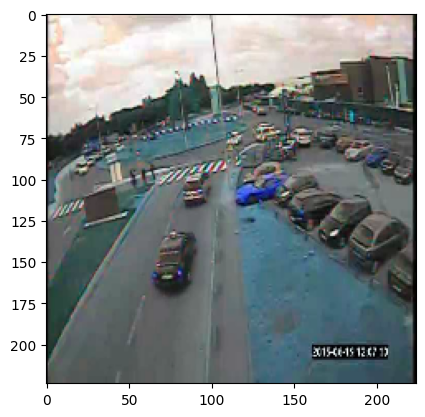

In [ ]:
plt.imshow(sample_images[3])

## pytorch equivalents

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:

class VehicleDetectionModel(nn.Module):
    def __init__(self, num_classes):
        super(VehicleDetectionModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=0)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=0)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=0)
        self.flatten = nn.Flatten()
        self.dense1 = nn.Linear(64 * 26 * 26, 64)  # Calculate input features based on pooling
        self.vehicle_class = nn.Linear(64, num_classes)
        self.bounding_box = nn.Linear(64, 4)

    def forward(self, x):
        x = x.permute(0, 3, 1, 2) # Transpose input for PyTorch
        x = self.relu(self.conv1(x))
        x = self.maxpool(x)
        x = self.relu(self.conv2(x))
        x = self.maxpool(x)
        x = self.relu(self.conv3(x))
        x = self.flatten(x)
        x = self.relu(self.dense1(x))

        vehicle_class_output = self.vehicle_class(x)
        bounding_box_output = self.bounding_box(x)

        return vehicle_class_output, bounding_box_output




In [ ]:
# Instantiate the PyTorch model
num_classes = len(unique_labels)
pytorch_model = VehicleDetectionModel(num_classes)

In [ ]:
X_train, X_test, y_train, y_test, bbox_train, bbox_test = train_test_split(processed_images, labels, bounding_boxes, test_size=0.2, random_state=42)

In [ ]:
criterion_class = nn.CrossEntropyLoss()
criterion_bbox = nn.MSELoss()
optimizer = optim.Adam(pytorch_model.parameters())

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pytorch_model.to(device)
print(f"Using device: {device}")

In [ ]:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
bbox_train_tensor = torch.tensor(bbox_train, dtype=torch.float32).to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)
bbox_test_tensor = torch.tensor(bbox_test, dtype=torch.float32).to(device)

In [ ]:

epochs = 3
for epoch in range(epochs):
    pytorch_model.train()
    running_loss = 0.0
    running_class_loss = 0.0
    running_bbox_loss = 0.0

    class_preds, bbox_preds = pytorch_model(X_train_tensor)

    loss_class = criterion_class(class_preds, y_train_tensor)
    loss_bbox = criterion_bbox(bbox_preds, bbox_train_tensor)
    total_loss = loss_class + loss_bbox

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    running_loss += total_loss.item()
    running_class_loss += loss_class.item()
    running_bbox_loss += loss_bbox.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}, Class Loss: {running_class_loss:.4f}, Bbox Loss: {running_bbox_loss:.4f}")


In [ ]:

# epochs = 3
# for epoch in range(epochs):
#     pytorch_model.train()
#     running_loss = 0.0
#     running_class_loss = 0.0
#     running_bbox_loss = 0.0

#     class_preds, bbox_preds = pytorch_model(X_train_tensor)

#     loss_class = criterion_class(class_preds, y_train_tensor)
#     loss_bbox = criterion_bbox(bbox_preds, bbox_train_tensor)
#     total_loss = loss_class + loss_bbox

#     optimizer.zero_grad()
#     total_loss.backward()
#     optimizer.step()

#     running_loss += total_loss.item()
#     running_class_loss += loss_class.item()
#     running_bbox_loss += loss_bbox.item()

#     print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}, Class Loss: {running_class_loss:.4f}, Bbox Loss: {running_bbox_loss:.4f}")

#     # Evaluation loop
#     pytorch_model.eval()
#     test_loss = 0.0
#     test_class_loss = 0.0
#     test_bbox_loss = 0.0
#     correct_predictions = 0
#     total_samples = 0
#     test_mae = 0.0

#     with torch.no_grad():
#         class_preds_test, bbox_preds_test = pytorch_model(X_test_tensor)

#         loss_class_test = criterion_class(class_preds_test, y_test_tensor)
#         loss_bbox_test = criterion_bbox(bbox_preds_test, bbox_test_tensor)
#         total_loss_test = loss_class_test + loss_bbox_test

#         test_loss += total_loss_test.item()
#         test_class_loss += loss_class_test.item()
#         test_bbox_loss += loss_bbox_test.item()

#         # Calculate accuracy for classification
#         _, predicted_classes = torch.max(class_preds_test, 1)
#         correct_predictions += (predicted_classes == y_test_tensor).sum().item()
#         total_samples += y_test_tensor.size(0)

#         # Calculate MAE for bounding box regression
#         test_mae += torch.mean(torch.abs(bbox_preds_test - bbox_test_tensor)).item()


#     accuracy = correct_predictions / total_samples
#     average_test_mae = test_mae / 1 # Divide by number of batches, which is 1 in this case

#     print(f"Epoch {epoch+1}/{epochs}, Test Loss: {test_loss:.4f}, Test Class Loss: {test_class_loss:.4f}, Test Bbox Loss: {test_bbox_loss:.4f}, Test Accuracy: {accuracy:.4f}, Test MAE: {average_test_mae:.4f}")


Using device: cpu


# inference

In [ ]:
pytorch_model.eval()

with torch.no_grad():
    class_preds_test, bbox_preds_test = pytorch_model(X_test_tensor)